1. ##### Importação das Bibliotecas e Conjunto de Dados

In [46]:
# instalando ferramentas e pacotes necessários:
'''!pip install feature-engine
!pip install scikit-optimize
!pip install scikit-metrics
!pip install imblearn'''

'!pip install feature-engine\n!pip install scikit-optimize\n!pip install scikit-metrics\n!pip install imblearn'

Importando as ferramentas essenciais para carregar, manipular, analisar e visualizar os dados:

In [47]:
#análise
import pandas as pd
import numpy as np

#visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()


In [48]:
#dividindo a base de dados
from sklearn.model_selection import train_test_split

#tratando dados categóricos e numéricos
from sklearn.preprocessing import MinMaxScaler

#classificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
#from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, confusion_matrix)
from imblearn.over_sampling import SMOTE

#metricas de avaliação de qualidade - SMOTE -
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV

#removendo aviso de erro para o BayesSearchCV
import warnings
warnings.filterwarnings('ignore', message='The objective has been evaluated at this point before.')

# Inspecionando os modelos
from sklearn.inspection import permutation_importance

In [49]:
# Carregando conjunto de dados:
df = pd.read_csv("D:/arquivo/jhonata/TI/PROJETOS/CLASSIFICACAO_RISCO_DE_CHURN/Datasets/BankChurners.csv", encoding='utf-8')
Metadados_df = pd.read_excel("D:/arquivo/jhonata/TI/PROJETOS/CLASSIFICACAO_RISCO_DE_CHURN/Datasets/metadados.xlsx")

###### Analisando os dados:

In [50]:
#lendo as 5 primeiras linhas
df.iloc[0:5]

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [51]:
#verificando os tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

##### 2. Tratamento dos Dados


In [52]:
#Renomeando Colunas
traducao_colunas = {
    'CLIENTNUM': 'ID_Cliente',
    'Attrition_Flag': 'Status_Churn',
    'Customer_Age': 'Idade_Cliente',
    'Gender' : 'Genero',
    'Dependent_count': 'Num_Dependentes',
    'Education_Level': 'Escolaridade',
    'Marital_Status': 'Estado_Civil',
    'Income_Category': 'Faixa_Renda',
    'Card_Category': 'Categoria_Cartao',
    'Months_on_book': 'Meses_Como_Cliente',
    'Total_Relationship_Count': 'Cont_Total_Relacionamento',
    'Months_Inactive_12_mon': 'Meses_Inativo_12m',
    'Contacts_Count_12_mon': 'Cont_Contatos_12m',
    'Credit_Limit': 'Limite_Credito',
    'Total_Revolving_Bal': 'Saldo_Rotativo_Total',
    'Avg_Open_To_Buy': 'Media_Disponivel_Compra',
    'Total_Amt_Chng_Q4_Q1': 'Var_Total_Valor_Q4_Q1',
    'Total_Trans_Amt': 'Valor_Total_Transacoes',
    'Total_Trans_Ct': 'Cont_Total_Transacoes',
    'Total_Ct_Chng_Q4_Q1': 'Var_Total_Cont_Q4_Q1',
    'Avg_Utilization_Ratio': 'Taxa_Media_Utilizacao',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1': 'Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2': 'Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida2'
}
#Renomeando linhas
traducao_valores = {
    #Valores da coluna 'Attrition_Flag'
    'Existing Customer' : 'Cliente Ativo',
    'Attrited Customer' : 'Cliente com Churn',
        #Valores da coluna 'Gender'
    'M' : 'Masculino',
    'F' : 'Feminino',
    #Valores da coluna 'Education_Level'
    'High School' : 'Ensino Medio',
    'Graduate' : 'Graduacao',
    'Uneducated' : 'Sem instrucao',
    'College' : 'Graduacao Incompleta',
    'Post-Graduate' : 'Pos-Graduacao',
    'Doctorate' : 'Doutorado',
    'Unknown' : 'Nao Informado',
    #Valores da coluna 'Marital_Status'
    'Married': 'Casado(a)',
    'Single': 'Solteiro(a)',
    'Divorced': 'Divorciado(a)',
    'Unknown': 'Nao Informado'    
}

#substituindo as colunas(traduzindo para melhor compreensão)

df_colunas_reanomeadas = df.rename(columns=traducao_colunas)

#substituindo os valores das células(traduzindo para melhor compreensão)

df_valores_renomeados = df_colunas_reanomeadas.replace(traducao_valores)





# Atribuindo o resultado final ao DataFrame Churn_df:
Churn_df = df_valores_renomeados


In [53]:
#lendo as 5 primeiras linhas novamente para verificar alterações
Churn_df.head()

,ID_Cliente,Status_Churn,Idade_Cliente,Genero,Num_Dependentes,Escolaridade,Estado_Civil,Faixa_Renda,Categoria_Cartao,Meses_Como_Cliente,...,Limite_Credito,Saldo_Rotativo_Total,Media_Disponivel_Compra,Var_Total_Valor_Q4_Q1,Valor_Total_Transacoes,Cont_Total_Transacoes,Var_Total_Cont_Q4_Q1,Taxa_Media_Utilizacao,Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida1,Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida2
0,768805383,Cliente Ativo,45,Masculino,3,Ensino Medio,Casado(a),$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Cliente Ativo,49,Feminino,5,Graduacao,Solteiro(a),Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Cliente Ativo,51,Masculino,3,Graduacao,Casado(a),$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Cliente Ativo,40,Feminino,4,Ensino Medio,Nao Informado,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Cliente Ativo,40,Masculino,3,Sem instrucao,Casado(a),$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [54]:
#verificando dimensão
Churn_df.shape

(10127, 23)

In [55]:
#verificando a quantidade de nulos
Churn_df.isna().sum()

ID_Cliente                                                                                                                0
Status_Churn                                                                                                              0
Idade_Cliente                                                                                                             0
Genero                                                                                                                    0
Num_Dependentes                                                                                                           0
Escolaridade                                                                                                              0
Estado_Civil                                                                                                              0
Faixa_Renda                                                                                                               0
Categori

In [56]:
#Agrupando Churn de Clientes por userid
Churn_UserId = Churn_df.groupby("Status_Churn")["ID_Cliente"].count().reset_index()
print(Churn_UserId)

        Status_Churn  ID_Cliente
0      Cliente Ativo        8500
1  Cliente com Churn        1627


In [57]:
#Criando nova coluna CHURN e atribuindo valores numéricos:
Churn_df['Churn'] = Churn_df['Status_Churn'].map({'Cliente com Churn' : 1, 'Cliente Ativo' : 0})
print(Churn_df['Churn'])

0        0
1        0
2        0
3        0
4        0
        ..
10122    0
10123    1
10124    1
10125    1
10126    1
Name: Churn, Length: 10127, dtype: int64


In [58]:
#Verificando dados alterados:
Churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 24 columns):
 #   Column                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                  --------------  -----  
 0   ID_Cliente                                                                                                              10127 non-null  int64  
 1   Status_Churn                                                                                                            10127 non-null  object 
 2   Idade_Cliente                                                                                                           10127 non-null  int64  
 3   Genero                                                                                                                  10127 non-null  objec

In [59]:
#Verificando as estatísticas descritivas
Churn_df.describe()

,ID_Cliente,Idade_Cliente,Num_Dependentes,Meses_Como_Cliente,Cont_Total_Relacionamento,Meses_Inativo_12m,Cont_Contatos_12m,Limite_Credito,Saldo_Rotativo_Total,Media_Disponivel_Compra,Var_Total_Valor_Q4_Q1,Valor_Total_Transacoes,Cont_Total_Transacoes,Var_Total_Cont_Q4_Q1,Taxa_Media_Utilizacao,Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida1,Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida2,Churn
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003,0.160660
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301,0.367235
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660,0.000000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820,0.000000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900,0.000000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990,1.000000


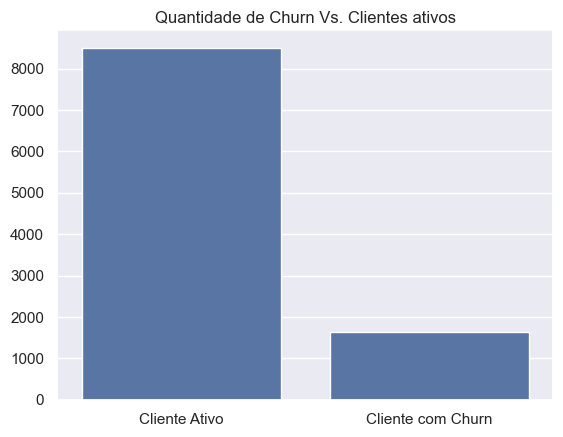

In [60]:
#Gráfico de barras da quantidade de clientes que deram churn(Attrited customer)-(1) e que não deram churn(Existing Customer)-(0):
sns.barplot(data=Churn_UserId, x = "Status_Churn", y = "ID_Cliente")
plt.title('Quantidade de Churn Vs. Clientes ativos')
plt.xlabel('')
plt.ylabel('')
plt.show()

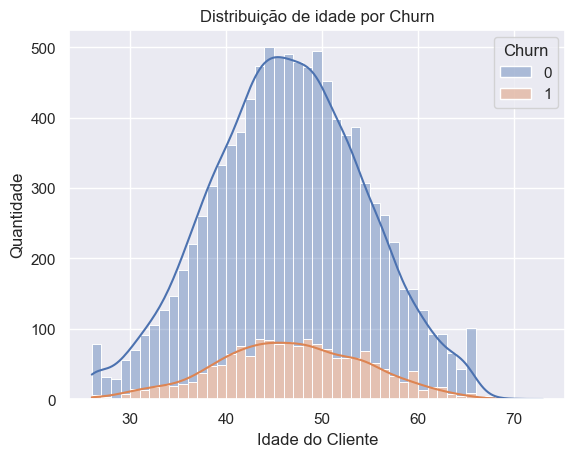

In [61]:
#histograma de distribuição de idade por Churn:
sns.histplot(data=Churn_df, x='Idade_Cliente', hue='Churn', kde=True, multiple='stack', alpha=0.4)
plt.title('Distribuição de idade por Churn')
plt.xlabel('Idade do Cliente')
plt.ylabel('Quantidade')
plt.show()

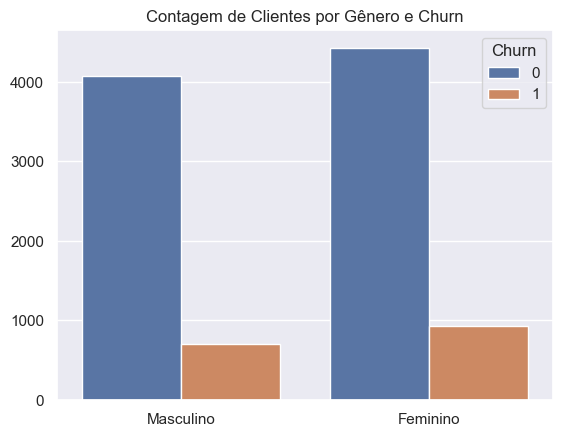

In [62]:
#gráfico de contagem de clientes por gênero e churn:
sns.countplot(x='Genero', hue='Churn', data=Churn_df)
plt.title('Contagem de Clientes por Gênero e Churn')
plt.xlabel('')
plt.ylabel('')
plt.show()

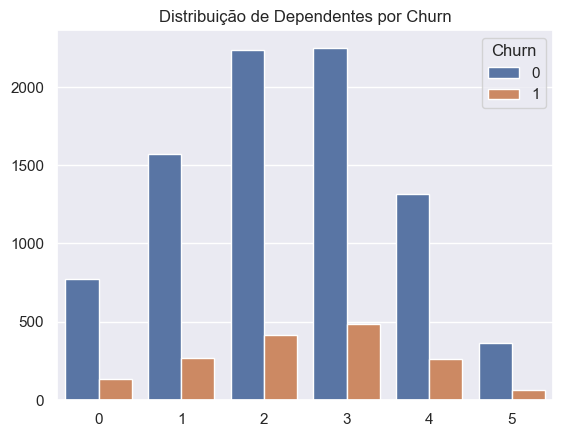

In [63]:
#gráfico de contagem de Distribuição de Dependentes por Churn
sns.countplot(x='Num_Dependentes', hue='Churn', data=Churn_df)
plt.title('Distribuição de Dependentes por Churn')
plt.xlabel('')
plt.ylabel('')
plt.show()

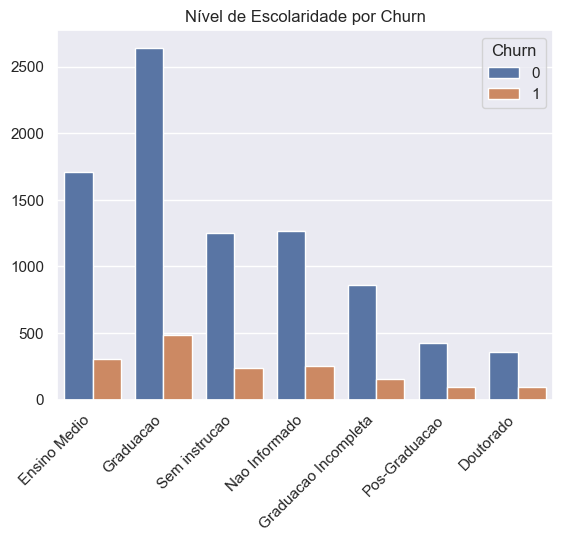

In [64]:
#gráfico de contagem de Escolaridade por Churn
sns.countplot(x='Escolaridade', hue='Churn', data=Churn_df)
plt.title('Nível de Escolaridade por Churn')
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('')
plt.show()

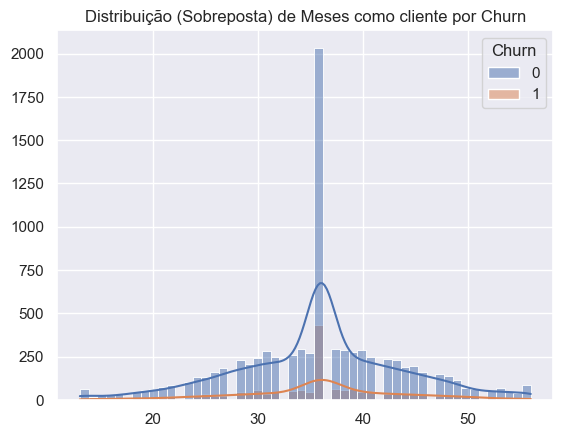

In [65]:
#gráfico de histograma de meses como cliente por Churn
sns.histplot(x='Meses_Como_Cliente', hue='Churn', data=Churn_df, kde=True, multiple='layer', alpha=0.5)
plt.title('Distribuição (Sobreposta) de Meses como cliente por Churn')
plt.xlabel('')
plt.ylabel('')
plt.show()

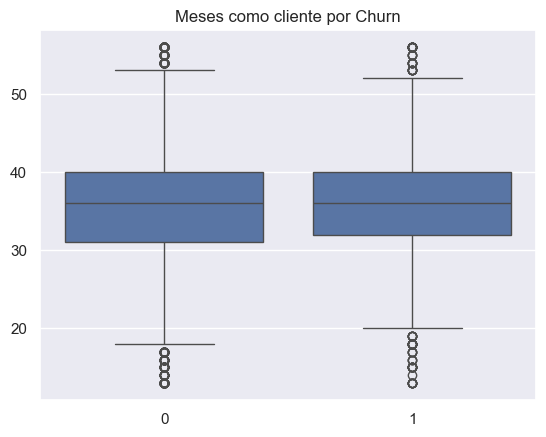

In [66]:
#gráfico de caixa de Meses como cliente por Churn
sns.boxplot(x='Churn', y='Meses_Como_Cliente', data=Churn_df)
plt.title('Meses como cliente por Churn')
plt.xlabel('')
plt.ylabel('')
plt.show()

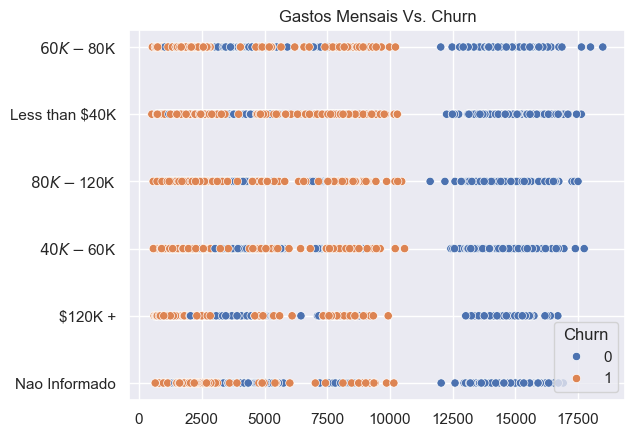

In [67]:
# gráfico de dispersão
sns.scatterplot(x='Valor_Total_Transacoes', y='Faixa_Renda', hue='Churn', data=Churn_df)
plt.title('Gastos Mensais Vs. Churn')
plt.xlabel('')
plt.ylabel('')
plt.show()

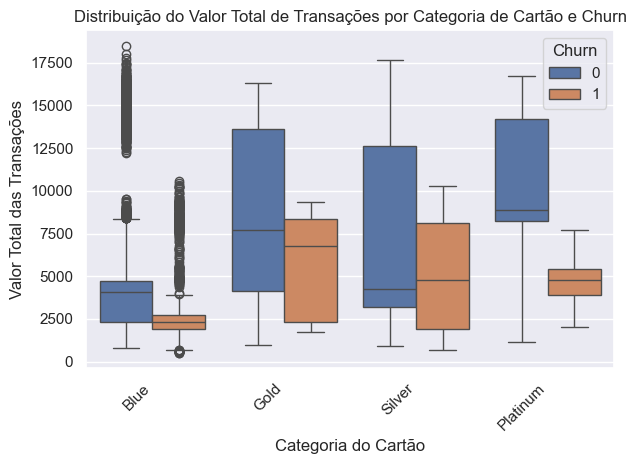

In [68]:
#gráfico de caixa Distribuição do Valor Total de Transações por Categoria de Cartão e Churn
sns.boxplot(x='Categoria_Cartao', y='Valor_Total_Transacoes', hue='Churn', data=Churn_df)
plt.title('Distribuição do Valor Total de Transações por Categoria de Cartão e Churn')
plt.xticks(rotation=45, ha='right') 
plt.xlabel('Categoria do Cartão') 
plt.ylabel('Valor Total das Transações') 
plt.tight_layout() 
plt.show()

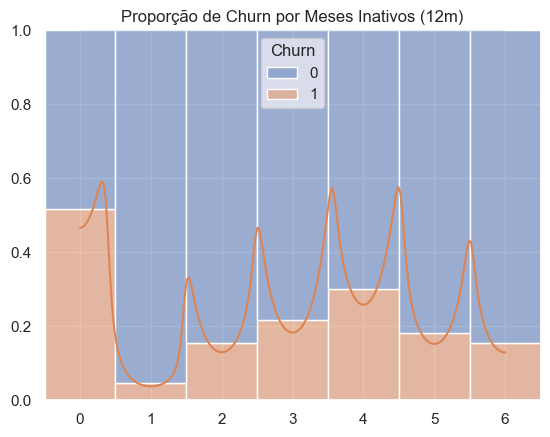

In [69]:
#gráfico de histograma para Proporção de Churn por Meses Inativos (12m)
sns.histplot(x='Meses_Inativo_12m',hue='Churn', kde=True, data=Churn_df,  multiple='fill', discrete=True, stat='probability')
plt.title('Proporção de Churn por Meses Inativos (12m)')
plt.xlabel('')
plt.ylabel('')
plt.show()

##### 3. Preparando e modelando os Dados

In [70]:
#conferindo DataFrame
Churn_df.head()

,ID_Cliente,Status_Churn,Idade_Cliente,Genero,Num_Dependentes,Escolaridade,Estado_Civil,Faixa_Renda,Categoria_Cartao,Meses_Como_Cliente,...,Saldo_Rotativo_Total,Media_Disponivel_Compra,Var_Total_Valor_Q4_Q1,Valor_Total_Transacoes,Cont_Total_Transacoes,Var_Total_Cont_Q4_Q1,Taxa_Media_Utilizacao,Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida1,Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida2,Churn
0,768805383,Cliente Ativo,45,Masculino,3,Ensino Medio,Casado(a),$60K - $80K,Blue,39,...,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991,0
1,818770008,Cliente Ativo,49,Feminino,5,Graduacao,Solteiro(a),Less than $40K,Blue,44,...,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994,0
2,713982108,Cliente Ativo,51,Masculino,3,Graduacao,Casado(a),$80K - $120K,Blue,36,...,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998,0
3,769911858,Cliente Ativo,40,Feminino,4,Ensino Medio,Nao Informado,Less than $40K,Blue,34,...,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987,0
4,709106358,Cliente Ativo,40,Masculino,3,Sem instrucao,Casado(a),$60K - $80K,Blue,21,...,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998,0


In [71]:
# calculando a medida estatística da curtose para os dados da coluna "Meses_Como_Cliente"
print('A curtose da coluna "Meses_Como_Cliente" é : {}'.format(Churn_df['Meses_Como_Cliente'].kurt()))

A curtose da coluna "Meses_Como_Cliente" é : 0.40010012019986707


In [72]:
le = LabelEncoder()
Categorical_cols = ['Genero', 'Escolaridade', 'Estado_Civil', 'Categoria_Cartao']
for col in Categorical_cols:
  Churn_df[col] = le.fit_transform(Churn_df[col])
  #conferindo a alteração
Churn_df.head()

,ID_Cliente,Status_Churn,Idade_Cliente,Genero,Num_Dependentes,Escolaridade,Estado_Civil,Faixa_Renda,Categoria_Cartao,Meses_Como_Cliente,...,Saldo_Rotativo_Total,Media_Disponivel_Compra,Var_Total_Valor_Q4_Q1,Valor_Total_Transacoes,Cont_Total_Transacoes,Var_Total_Cont_Q4_Q1,Taxa_Media_Utilizacao,Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida1,Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida2,Churn
0,768805383,Cliente Ativo,45,1,3,1,0,$60K - $80K,0,39,...,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991,0
1,818770008,Cliente Ativo,49,0,5,2,3,Less than $40K,0,44,...,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994,0
2,713982108,Cliente Ativo,51,1,3,2,0,$80K - $120K,0,36,...,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998,0
3,769911858,Cliente Ativo,40,0,4,1,2,Less than $40K,0,34,...,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987,0
4,709106358,Cliente Ativo,40,1,3,6,0,$60K - $80K,0,21,...,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998,0


In [73]:
#Normalização dos dados
scaler = MinMaxScaler()
numeric_features = ['Cont_Total_Relacionamento','Taxa_Media_Utilizacao', 'Meses_Como_Cliente', 'Valor_Total_Transacoes']
Churn_df[numeric_features] = scaler.fit_transform(Churn_df[numeric_features])
#conferindo a alteração
Churn_df.head()

,ID_Cliente,Status_Churn,Idade_Cliente,Genero,Num_Dependentes,Escolaridade,Estado_Civil,Faixa_Renda,Categoria_Cartao,Meses_Como_Cliente,...,Saldo_Rotativo_Total,Media_Disponivel_Compra,Var_Total_Valor_Q4_Q1,Valor_Total_Transacoes,Cont_Total_Transacoes,Var_Total_Cont_Q4_Q1,Taxa_Media_Utilizacao,Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida1,Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida2,Churn
0,768805383,Cliente Ativo,45,1,3,1,0,$60K - $80K,0,0.604651,...,777,11914.0,1.335,0.035273,42,1.625,0.061061,0.000093,0.99991,0
1,818770008,Cliente Ativo,49,0,5,2,3,Less than $40K,0,0.720930,...,864,7392.0,1.541,0.043452,33,3.714,0.105105,0.000057,0.99994,0
2,713982108,Cliente Ativo,51,1,3,2,0,$80K - $120K,0,0.534884,...,0,3418.0,2.594,0.076611,20,2.333,0.000000,0.000021,0.99998,0
3,769911858,Cliente Ativo,40,0,4,1,2,Less than $40K,0,0.488372,...,2517,796.0,1.405,0.036775,20,2.333,0.760761,0.000134,0.99987,0
4,709106358,Cliente Ativo,40,1,3,6,0,$60K - $80K,0,0.186047,...,0,4716.0,2.175,0.017025,28,2.500,0.000000,0.000022,0.99998,0


In [74]:
# 1. Definir X (features) e y (target)
# Colunas a serem removidas para criar X (ajuste conforme suas features finais)
print("--- Etapa 1: Definindo X e y ---")
cols_to_drop_for_X = [
    'ID_Cliente',
    'Churn',
    'Status_Churn',
    'Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida1',
    'Classificador_Naive_Bayes_Indicador_Evasao_CategCartao_ContContatos12M_NumDependentes_NivelEduc_MesesInativo12M_Saida2'
]

X = Churn_df.drop(columns=cols_to_drop_for_X, axis=1)


# Definindo y_alvo com uma Series Pandas 1D com 0s e 1s
y_alvo = Churn_df['Churn']

print("Shape de X:", X.shape)
print("Shape de y_alvo:", y_alvo.shape)
print("Primeiras linhas de X:")
print(X.head())
print("\nValores únicos em y_alvo:", y_alvo.unique())

# Codificar a variável alvo 'y' para numérica ANTES da divisão
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y_alvo) # y_encoded é agora um array NumPy 1D


--- Etapa 1: Definindo X e y ---
Shape de X: (10127, 19)
Shape de y_alvo: (10127,)
Primeiras linhas de X:
   Idade_Cliente  Genero  Num_Dependentes  Escolaridade  Estado_Civil  \
0             45       1                3             1             0   
1             49       0                5             2             3   
2             51       1                3             2             0   
3             40       0                4             1             2   
4             40       1                3             6             0   

      Faixa_Renda  Categoria_Cartao  Meses_Como_Cliente  \
0     $60K - $80K                 0            0.604651   
1  Less than $40K                 0            0.720930   
2    $80K - $120K                 0            0.534884   
3  Less than $40K                 0            0.488372   
4     $60K - $80K                 0            0.186047   

   Cont_Total_Relacionamento  Meses_Inativo_12m  Cont_Contatos_12m  \
0                        0.8  

In [75]:
# 2. Dividir em conjuntos de treino e teste ANTES de qualquer reamostragem ou escalonamento que cause data leakage
print("\n--- Etapa 2: Divisão Treino-Teste ---")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_alvo,
    test_size=0.25,       # 25% dos dados para teste
    random_state=42,      # Para reprodutibilidade
    stratify=y_alvo       # Para manter a proporção das classes em y
)
print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)


--- Etapa 2: Divisão Treino-Teste ---
Shape de X_train: (7595, 19)
Shape de X_test: (2532, 19)
Shape de y_train: (7595,)
Shape de y_test: (2532,)


In [76]:
# ETAPA 3: PRÉ-PROCESSAMENTO DAS FEATURES (APÓS A DIVISÃO)

# 3A. ONE-HOT ENCODING PARA COLUNAS CATEGÓRICAS EM X (com pd.get_dummies)
print("\n--- Etapa 3A: One-Hot Encoding (get_dummies) ---")
# Identificar colunas que ainda são do tipo 'object' (texto) em X_train
colunas_categoricas_para_dummies = X_train.select_dtypes(include='object').columns.tolist()

# Verificação IMPORTANTE:
print(f"Colunas categóricas identificadas em X_train para dummificar: {colunas_categoricas_para_dummies}")



if colunas_categoricas_para_dummies:
    print(f"Colunas categóricas para One-Hot Encoding: {colunas_categoricas_para_dummies}")
    X_train = pd.get_dummies(X_train, columns=colunas_categoricas_para_dummies, prefix=colunas_categoricas_para_dummies, dummy_na=False)
    X_test = pd.get_dummies(X_test, columns=colunas_categoricas_para_dummies, prefix=colunas_categoricas_para_dummies, dummy_na=False)

    # Alinhar colunas para garantir que X_test tenha as mesmas colunas que X_train
    # (preenchendo com 0 se alguma categoria do treino não existir no teste)
    X_train_cols = X_train.columns
    X_test = X_test.reindex(columns=X_train_cols, fill_value=0)
    # Garantir que X_train também só tenha essas colunas (caso raro de X_test ter uma categoria nova não vista no prefixo)
    X_train = X_train.reindex(columns=X_train_cols, fill_value=0)

    print("Shapes após get_dummies e alinhamento:")
    print("Shape de X_train:", X_train.shape)
    print("Shape de X_test:", X_test.shape)
else:
    print("Nenhuma coluna do tipo 'object' encontrada em X_train para aplicar pd.get_dummies.")
    # Isso aconteceria se todas as suas features em X já fossem numéricas.


--- Etapa 3A: One-Hot Encoding (get_dummies) ---
Colunas categóricas identificadas em X_train para dummificar: ['Faixa_Renda']
Colunas categóricas para One-Hot Encoding: ['Faixa_Renda']
Shapes após get_dummies e alinhamento:
Shape de X_train: (7595, 24)
Shape de X_test: (2532, 24)


In [77]:
#   3B. ESCALONAMENTO DE FEATURES NUMÉRICAS (MinMaxScaler)
print("\n--- Etapa 3B: Escalonamento (MinMaxScaler) ---")
# Neste ponto, todas as colunas em X_train e X_test devem ser numéricas.
# Vamos escalar todas elas.
colunas_para_escalar = X_train.columns # Todas as colunas de X_train

scaler = MinMaxScaler()

# Guardar índices para reconstrução (opcional, mas boa prática se precisar do índice original)
X_train_index = X_train.index
X_test_index = X_test.index

# Ajustar (fit) o scaler SOMENTE em X_train e transformar ambos
X_train_scaled_array = scaler.fit_transform(X_train[colunas_para_escalar])
X_test_scaled_array = scaler.transform(X_test[colunas_para_escalar])

# Converter de volta para DataFrames (mantendo nomes de colunas e índices)
X_train = pd.DataFrame(X_train_scaled_array, columns=colunas_para_escalar, index=X_train_index)
X_test = pd.DataFrame(X_test_scaled_array, columns=colunas_para_escalar, index=X_test_index)

print("Primeiras linhas de X_train escalado:")
print(X_train.head())


--- Etapa 3B: Escalonamento (MinMaxScaler) ---
Primeiras linhas de X_train escalado:
      Idade_Cliente  Genero  Num_Dependentes  Escolaridade  Estado_Civil  \
9524       0.553191     1.0              0.6      0.333333           0.0   
1586       0.234043     0.0              0.6      0.333333           1.0   
8615       0.404255     0.0              0.6      0.166667           0.0   
4667       0.361702     0.0              0.6      0.333333           1.0   
4887       0.382979     0.0              1.0      0.333333           1.0   

      Categoria_Cartao  Meses_Como_Cliente  Cont_Total_Relacionamento  \
9524               0.0            0.720930                        0.0   
1586               0.0            0.534884                        0.4   
8615               0.0            0.441860                        0.2   
4667               0.0            0.395349                        0.4   
4887               0.0            0.558140                        0.0   

      Meses_Inativ

In [78]:
# ETAPA 4: BALANCEAMENTO DAS CLASSES COM SMOTE (SOMENTE nos dados de treino)
print("\n--- Etapa 4: Balanceamento com SMOTE ---")
print(f"Contagem de classes em y_train ANTES do SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
smote = SMOTE(random_state=42)
# X_train e y_train aqui são os pré-processados da etapa anterior
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Contagem de classes em y_train APÓS o SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")
print("Shape de X_train_resampled:", X_train_resampled.shape)
print("Shape de y_train_resampled:", y_train_resampled.shape)


--- Etapa 4: Balanceamento com SMOTE ---
Contagem de classes em y_train ANTES do SMOTE: {0: 6375, 1: 1220}


Contagem de classes em y_train APÓS o SMOTE: {0: 6375, 1: 6375}
Shape de X_train_resampled: (12750, 24)
Shape de y_train_resampled: (12750,)



--- Etapa 5A: Modelagem (Exemplo Regressão Logística) ---

--- Regressão Logística ---

--- Resultados da Regressão Logística ---


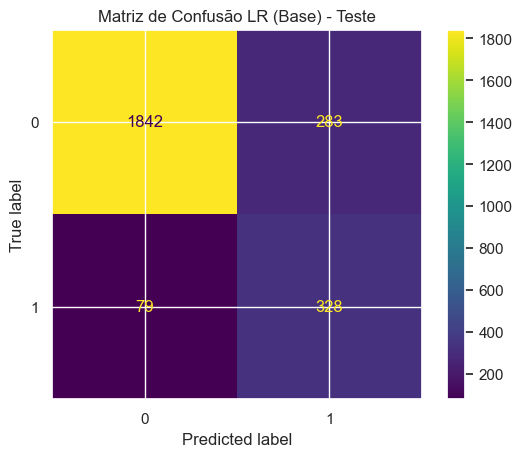

Acurácia LR (Treino Resampled): 0.8648627450980392
Acurácia LR (Teste): 0.8570300157977883
ROCAUC LR (Treino Resampled): 0.9382457085736255
ROCAUC LR (Teste): 0.9166330394565688


In [79]:
# ETAPA 5A: MODELAGEM (EXEMPLO COM REGRESSÃO LOGÍSTICA)
print("\n--- Etapa 5A: Modelagem (Exemplo Regressão Logística) ---")
# Usar X_train_resampled e y_train_resampled para treinar
# Usar X_test (processado) e y_test para avaliar

lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
lr_model.fit(X_train_resampled, y_train_resampled)

# Predições
y_pred_lr_train = lr_model.predict(X_train_resampled)
y_pred_lr_test = lr_model.predict(X_test)
y_proba_lr_test = lr_model.predict_proba(X_test)[:, 1]

# Modelagem com Regressão Logística
print("\n--- Regressão Logística ---")
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
lr_model.fit(X_train_resampled, y_train_resampled)

# Predições
y_pred_lr_train = lr_model.predict(X_train_resampled)
y_pred_lr_test = lr_model.predict(X_test)
y_proba_lr_train = lr_model.predict_proba(X_train_resampled)[:, 1]
y_proba_lr_test = lr_model.predict_proba(X_test)[:, 1]

# Avaliação
print("\n--- Resultados da Regressão Logística ---")
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, values_format="d") 
plt.title("Matriz de Confusão LR (Base) - Teste")                                  
plt.show()                                                                        

print(f"Acurácia LR (Treino Resampled): {accuracy_score(y_train_resampled, y_pred_lr_train)}")
print(f"Acurácia LR (Teste): {accuracy_score(y_test, y_pred_lr_test)}")
print(f"ROCAUC LR (Treino Resampled): {roc_auc_score(y_train_resampled, y_proba_lr_train)}")
print(f"ROCAUC LR (Teste): {roc_auc_score(y_test, y_proba_lr_test)}")
#print(classification_report(y_test, y_pred_lr_test))


--- Etapa 5B: Tuning da Regressão Logística ---
Iniciando o GridSearchCV para Regressão Logística...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores Parâmetros para Regressão Logística: {'C': 10, 'penalty': 'l2'}
Melhor Score ROCAUC (CV) para Regressão Logística: 0.9376323567858517

--- Resultados da Regressão Logística Tunada ---


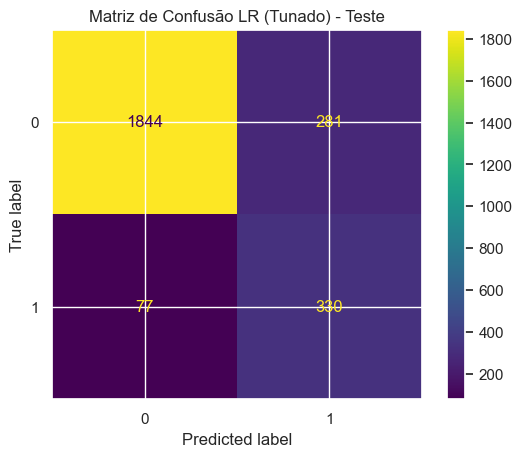

Acurácia LR Tuned (Treino Resampled): 0.8673725490196078
Acurácia LR Tuned (Teste): 0.858609794628752
Acurácia Balanceada LR Tuned (Treino Resampled): 0.8673725490196078
Acurácia Balanceada LR Tuned (Teste): 0.8392877583465819
Precision LR Tuned (Teste, pos_label=1): 0.5400981996726678
Recall LR Tuned (Teste, pos_label=1): 0.8108108108108109
F1-Score LR Tuned (Teste, pos_label=1): 0.6483300589390962
ROCAUC LR Tuned (Treino Resampled): 0.9386196447520185
ROCAUC LR Tuned (Teste): 0.9183778002601533


In [80]:
# --- ETAPA 5B: Tuning da Regressão Logística com GridSearchCV ---
print("\n--- Etapa 5B: Tuning da Regressão Logística ---")

# Definindo a grade de parâmetros que você quer testar
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100], # Adicionei 100 para testar regularização mais fraca
                 'penalty': ['l1', 'l2']}

# Criando o objeto GridSearchCV
# solver='liblinear' é uma boa escolha pois suporta tanto 'l1' quanto 'l2'
# Adicionar random_state ao LogisticRegression dentro do GridSearchCV para reprodutibilidade
grid_search_lr = GridSearchCV(
    LogisticRegression(solver='liblinear', random_state=42, max_iter=1000),
    param_grid_lr,
    scoring='roc_auc', # Usar roc_auc é geralmente bom para dados com histórico de desbalanceamento
    cv=5,              # Número de folds na validação cruzada
    n_jobs=-1,         # Usar todos os processadores disponíveis
    verbose=1          # Para ver o progresso do GridSearchCV
)

# Ajustando o GridSearchCV com os dados de treino reamostrados
print("Iniciando o GridSearchCV para Regressão Logística...")
grid_search_lr.fit(X_train_resampled, y_train_resampled)

# Obtendo o melhor estimador (modelo com os melhores parâmetros)
lr_tuned = grid_search_lr.best_estimator_

print(f"Melhores Parâmetros para Regressão Logística: {grid_search_lr.best_params_}")
print(f"Melhor Score ROCAUC (CV) para Regressão Logística: {grid_search_lr.best_score_}")

# --- Avaliação do Modelo de Regressão Logística Tunado ---
print("\n--- Resultados da Regressão Logística Tunada ---")

# Predições com o modelo tunado
y_pred_lr_tuned_train = lr_tuned.predict(X_train_resampled)
y_pred_lr_tuned_test = lr_tuned.predict(X_test)
y_proba_lr_tuned_train = lr_tuned.predict_proba(X_train_resampled)[:, 1]
y_proba_lr_tuned_test = lr_tuned.predict_proba(X_test)[:, 1]

# Matriz de Confusão
ConfusionMatrixDisplay.from_estimator(lr_tuned, X_test, y_test, values_format="d")
plt.title("Matriz de Confusão LR (Tunado) - Teste")
plt.show()

# Métricas
print(f"Acurácia LR Tuned (Treino Resampled): {accuracy_score(y_train_resampled, y_pred_lr_tuned_train)}")
print(f"Acurácia LR Tuned (Teste): {accuracy_score(y_test, y_pred_lr_tuned_test)}")
print(f"Acurácia Balanceada LR Tuned (Treino Resampled): {balanced_accuracy_score(y_train_resampled, y_pred_lr_tuned_train)}") # Adicionando Acurácia Balanceada
print(f"Acurácia Balanceada LR Tuned (Teste): {balanced_accuracy_score(y_test, y_pred_lr_tuned_test)}")                  # Adicionando Acurácia Balanceada
print(f"Precision LR Tuned (Teste, pos_label=1): {precision_score(y_test, y_pred_lr_tuned_test, pos_label=1)}")         # Adicionando Precision
print(f"Recall LR Tuned (Teste, pos_label=1): {recall_score(y_test, y_pred_lr_tuned_test, pos_label=1)}")                # Adicionando Recall
print(f"F1-Score LR Tuned (Teste, pos_label=1): {f1_score(y_test, y_pred_lr_tuned_test, pos_label=1)}")                   # Adicionando F1-Score
print(f"ROCAUC LR Tuned (Treino Resampled): {roc_auc_score(y_train_resampled, y_proba_lr_tuned_train)}")
print(f"ROCAUC LR Tuned (Teste): {roc_auc_score(y_test, y_proba_lr_tuned_test)}")

#  classification_report completo para o modelo tunado
#print("\nRelatório de Classificação Regressão Logística Tuned (Teste):")
#print(classification_report(y_test, y_pred_lr_tuned_test))


--- Random Forest (Base) ---
Treinando o modelo Random Forest (Base)...


Treinamento concluído.

--- Resultados do Random Forest (Base) ---


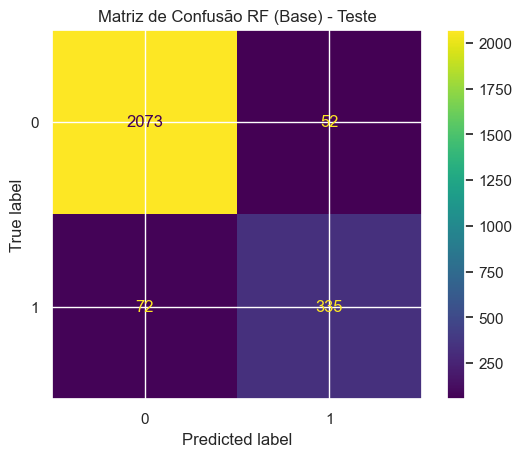


Métricas de Treino (Resampled) para Random Forest (Base):
Acurácia: 1.0
Acurácia Balanceada: 1.0
Precision (pos_label=1): 1.0
Recall (pos_label=1): 1.0
F1-Score (pos_label=1): 1.0
ROCAUC: 1.0

Métricas de Teste para Random Forest (Base):
Acurácia: 0.9510268562401264
Acurácia Balanceada: 0.8993126174302645
Precision (pos_label=1): 0.8656330749354005
Recall (pos_label=1): 0.8230958230958231
F1-Score (pos_label=1): 0.8438287153652393
ROCAUC: 0.9828339355398179


In [81]:
# --- Random Forest (Base) ---
print("\n--- Random Forest (Base) ---")

# 1. Criar a instância do modelo Random Forest
#    Adicionar random_state para reprodutibilidade
rf_model_base = RandomForestClassifier(random_state=42) # Usando um novo nome para clareza

# 2. Treinar o modelo com os dados de treino reamostrados
print("Treinando o modelo Random Forest (Base)...")
rf_model_base.fit(X_train_resampled, y_train_resampled)
print("Treinamento concluído.")

# 3. Fazer predições
# Predições no conjunto de treino (reamostrado)
y_pred_rf_base_train = rf_model_base.predict(X_train_resampled)
y_proba_rf_base_train = rf_model_base.predict_proba(X_train_resampled)[:, 1]

# Predições no conjunto de teste
y_pred_rf_base_test = rf_model_base.predict(X_test)
y_proba_rf_base_test = rf_model_base.predict_proba(X_test)[:, 1]

# 4. Avaliação do modelo
print("\n--- Resultados do Random Forest (Base) ---")

# Matriz de Confusão para o conjunto de teste
ConfusionMatrixDisplay.from_estimator(rf_model_base, X_test, y_test, values_format="d")
plt.title("Matriz de Confusão RF (Base) - Teste")
plt.show()

# Métricas para Treino (Resampled)
print("\nMétricas de Treino (Resampled) para Random Forest (Base):")
print(f"Acurácia: {accuracy_score(y_train_resampled, y_pred_rf_base_train)}")
print(f"Acurácia Balanceada: {balanced_accuracy_score(y_train_resampled, y_pred_rf_base_train)}")
print(f"Precision (pos_label=1): {precision_score(y_train_resampled, y_pred_rf_base_train, pos_label=1, zero_division=0)}")
print(f"Recall (pos_label=1): {recall_score(y_train_resampled, y_pred_rf_base_train, pos_label=1, zero_division=0)}")
print(f"F1-Score (pos_label=1): {f1_score(y_train_resampled, y_pred_rf_base_train, pos_label=1, zero_division=0)}")
print(f"ROCAUC: {roc_auc_score(y_train_resampled, y_proba_rf_base_train)}")

# Métricas para Teste
print("\nMétricas de Teste para Random Forest (Base):")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf_base_test)}")
print(f"Acurácia Balanceada: {balanced_accuracy_score(y_test, y_pred_rf_base_test)}")
print(f"Precision (pos_label=1): {precision_score(y_test, y_pred_rf_base_test, pos_label=1, zero_division=0)}")
print(f"Recall (pos_label=1): {recall_score(y_test, y_pred_rf_base_test, pos_label=1, zero_division=0)}")
print(f"F1-Score (pos_label=1): {f1_score(y_test, y_pred_rf_base_test, pos_label=1, zero_division=0)}")
print(f"ROCAUC: {roc_auc_score(y_test, y_proba_rf_base_test)}")

#print("\nRelatório de Classificação Random Forest (Base) - Teste:")
#print(classification_report(y_test, y_pred_rf_base_test, zero_division=0))


--- Random Forest (Tuning) ---
Iniciando o GridSearchCV para Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
GridSearchCV concluído.

Melhores Parâmetros para Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Melhor Score ROCAUC (CV) para Random Forest: 0.9972222745098039

--- Resultados do Random Forest (Tunado) ---


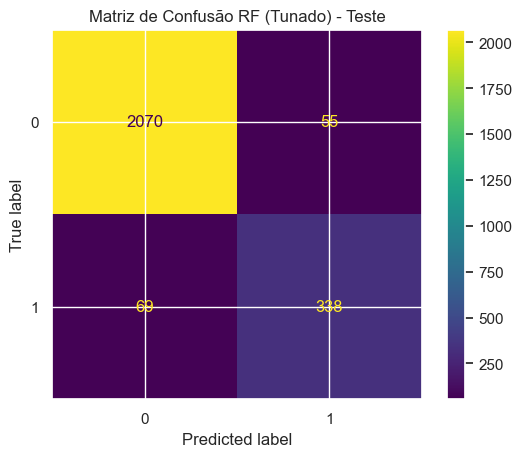


Métricas de Treino (Resampled) para Random Forest (Tunado):
Acurácia: 1.0
Acurácia Balanceada: 1.0
Precision (pos_label=1): 1.0
Recall (pos_label=1): 1.0
F1-Score (pos_label=1): 1.0
ROCAUC: 1.0

Métricas de Teste para Random Forest (Tunado):
Acurácia: 0.9510268562401264
Acurácia Balanceada: 0.9022922387628269
Precision (pos_label=1): 0.8600508905852418
Recall (pos_label=1): 0.8304668304668305
F1-Score (pos_label=1): 0.845
ROCAUC: 0.9835820205231969


In [82]:
# --- Tuning da Random Forest com GridSearchCV ---
print("\n--- Random Forest (Tuning) ---")

# 1. Definir a grade de hiperparâmetros para testar
# Usando um param_grid similar ao que gerou seus bons resultados anteriores
param_grid_rf = {
    'n_estimators': [100, 200, 300],  # Número de árvores
    'max_depth': [10, 15, None],       # Profundidade máxima. None = sem limite.
    'min_samples_split': [2, 5, 10],   # Mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4]      # Mínimo de amostras em um nó folha
}
# Você pode ajustar esta grade conforme necessário.
# Uma grade menor (como a que você usou antes: {'n_estimators': [100, 200], 'max_depth': [10, 15], 'min_samples_split': [2, 5]})
# rodará mais rápido. Esta é um pouco mais expandida.

# 2. Criar o objeto GridSearchCV
#    - RandomForestClassifier(random_state=42) para reprodutibilidade do classificador base.
#    - scoring='roc_auc' é uma boa métrica para otimizar, especialmente com dados que foram desbalanceados.
#    - cv=3 (ou 5) para o número de folds da validação cruzada. cv=3 é mais rápido.
#    - n_jobs=-1 para usar todos os processadores disponíveis.
#    - verbose=1 para ver o progresso.
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 3. Ajustar o GridSearchCV com os dados de treino reamostrados
print("Iniciando o GridSearchCV para Random Forest...")
grid_search_rf.fit(X_train_resampled, y_train_resampled)
print("GridSearchCV concluído.")

# 4. Obter o melhor estimador (modelo com os melhores parâmetros) e os melhores parâmetros
rf_tuned = grid_search_rf.best_estimator_
print(f"\nMelhores Parâmetros para Random Forest: {grid_search_rf.best_params_}")
print(f"Melhor Score ROCAUC (CV) para Random Forest: {grid_search_rf.best_score_}")



# 5. Fazer predições com o modelo tunado
# Predições no conjunto de treino (reamostrado)
y_pred_rf_tuned_train = rf_tuned.predict(X_train_resampled)
y_proba_rf_tuned_train = rf_tuned.predict_proba(X_train_resampled)[:, 1]

# Predições no conjunto de teste
y_pred_rf_tuned_test = rf_tuned.predict(X_test)
y_proba_rf_tuned_test = rf_tuned.predict_proba(X_test)[:, 1]

# 6. Avaliação do modelo tunado
print("\n--- Resultados do Random Forest (Tunado) ---")

# Matriz de Confusão para o conjunto de teste
ConfusionMatrixDisplay.from_estimator(rf_tuned, X_test, y_test, values_format="d")
plt.title("Matriz de Confusão RF (Tunado) - Teste")
plt.show()

# Métricas para Treino (Resampled)
print("\nMétricas de Treino (Resampled) para Random Forest (Tunado):")
print(f"Acurácia: {accuracy_score(y_train_resampled, y_pred_rf_tuned_train)}")
print(f"Acurácia Balanceada: {balanced_accuracy_score(y_train_resampled, y_pred_rf_tuned_train)}")
print(f"Precision (pos_label=1): {precision_score(y_train_resampled, y_pred_rf_tuned_train, pos_label=1, zero_division=0)}")
print(f"Recall (pos_label=1): {recall_score(y_train_resampled, y_pred_rf_tuned_train, pos_label=1, zero_division=0)}")
print(f"F1-Score (pos_label=1): {f1_score(y_train_resampled, y_pred_rf_tuned_train, pos_label=1, zero_division=0)}")
print(f"ROCAUC: {roc_auc_score(y_train_resampled, y_proba_rf_tuned_train)}")

# Métricas para Teste
print("\nMétricas de Teste para Random Forest (Tunado):")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf_tuned_test)}")
print(f"Acurácia Balanceada: {balanced_accuracy_score(y_test, y_pred_rf_tuned_test)}")
print(f"Precision (pos_label=1): {precision_score(y_test, y_pred_rf_tuned_test, pos_label=1, zero_division=0)}")
print(f"Recall (pos_label=1): {recall_score(y_test, y_pred_rf_tuned_test, pos_label=1, zero_division=0)}")
print(f"F1-Score (pos_label=1): {f1_score(y_test, y_pred_rf_tuned_test, pos_label=1, zero_division=0)}")
print(f"ROCAUC: {roc_auc_score(y_test, y_proba_rf_tuned_test)}")

#print("\nRelatório de Classificação Random Forest (Tunado) - Teste:")
#print(classification_report(y_test, y_pred_rf_tuned_test, zero_division=0))

Analisando qual melhor modelo de regressão:

In [83]:
#Métricas
print(f"Acurácia (Treino): {accuracy_score(y_train, lr_model.predict(X_train))}")
print(f"Acurácia (Teste): {accuracy_score(y_test, lr_model.predict(X_test))}")
print("====================================")
print(f"Acurácia Balanceada (Treino): {balanced_accuracy_score(y_train, lr_model.predict(X_train))}")
print(f"Acurácia Balanceada (Teste): {balanced_accuracy_score(y_test, lr_model.predict(X_test))}")
print("====================================")
print(f"Precision (Treino): {precision_score(y_train, lr_model.predict(X_train))}")
print(f"Precision (Teste): {precision_score(y_test, lr_model.predict(X_test))}")
print("====================================")
print(f"Recall (Treino): {recall_score(y_train, lr_model.predict(X_train))}")
print(f"Recall (Teste): {recall_score(y_test, lr_model.predict(X_test))}")
print("====================================")
print(f"F1-Score (Treino): {f1_score(y_train, lr_model.predict(X_train))}")
print(f"F1-Score (Teste): {f1_score(y_test, lr_model.predict(X_test))}")
print("====================================")
print(f"ROCAUC (Treino): {roc_auc_score(y_train, lr_model.predict_proba(X_train)[:,1])}")
print(f"ROCAUC (Teste): {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])}")

Acurácia (Treino): 0.8558262014483212
Acurácia (Teste): 0.8570300157977883
Acurácia Balanceada (Treino): 0.8538019929283189
Acurácia Balanceada (Teste): 0.8363601676542853
Precision (Treino): 0.5320348539210661
Precision (Teste): 0.5368248772504092
Recall (Treino): 0.8508196721311475
Recall (Teste): 0.8058968058968059
F1-Score (Treino): 0.6546830652790918
F1-Score (Teste): 0.6444007858546169
ROCAUC (Treino): 0.9284910318225652
ROCAUC (Teste): 0.9166330394565688


C:\Users\jhona\AppData\Local\Temp\ipykernel_19388\1707358270.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia_Absoluta', y='Feature', data=importancia_rl_df, palette='viridis')


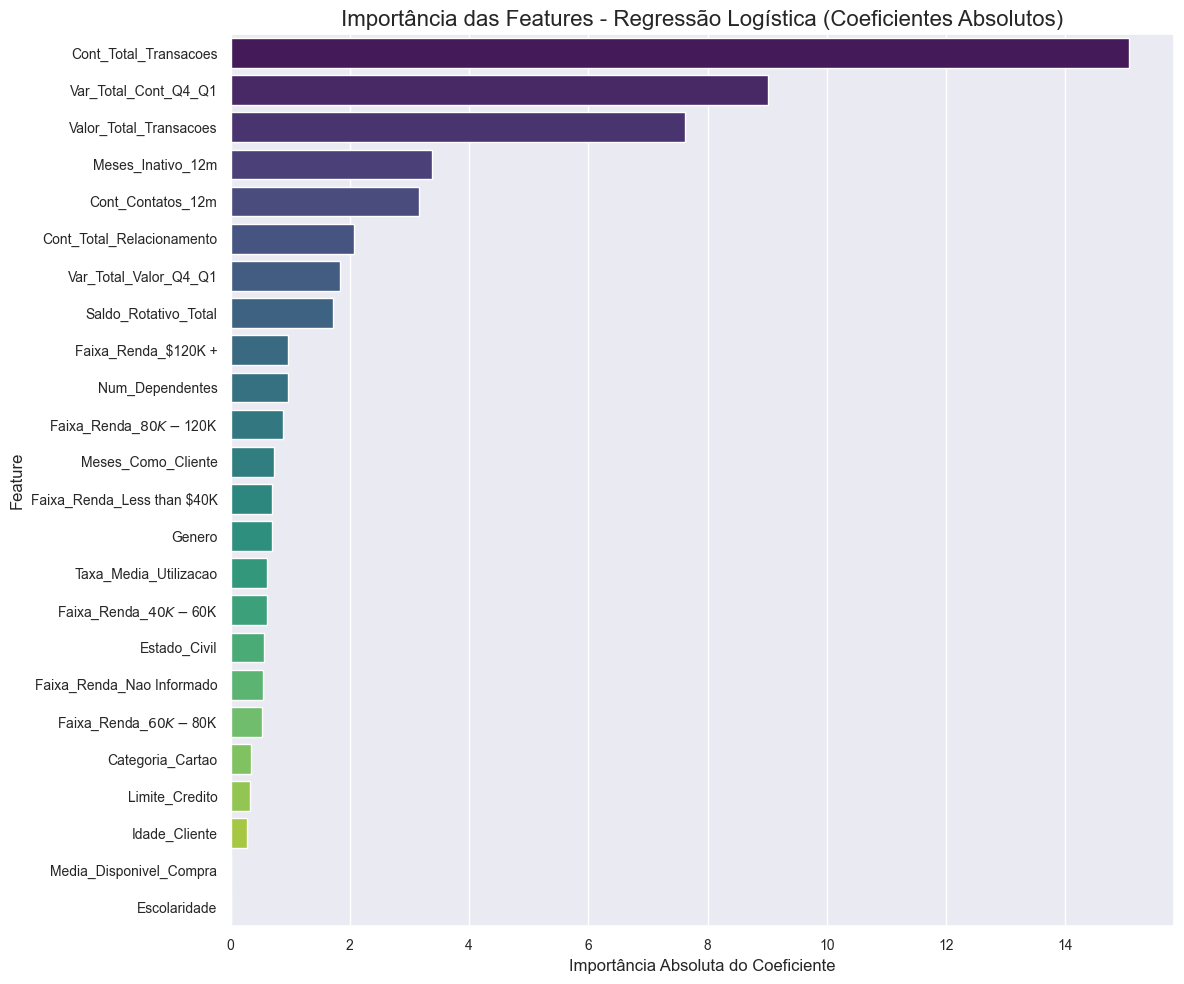


Importância das Features (Regressão Logística):

                       Feature  Coeficiente  Importancia_Absoluta
15       Cont_Total_Transacoes   -15.066410             15.066410
16        Var_Total_Cont_Q4_Q1    -9.019342              9.019342
14      Valor_Total_Transacoes     7.612180              7.612180
8            Meses_Inativo_12m     3.379799              3.379799
9            Cont_Contatos_12m     3.163293              3.163293
7    Cont_Total_Relacionamento    -2.060764              2.060764
13       Var_Total_Valor_Q4_Q1    -1.834969              1.834969
11        Saldo_Rotativo_Total    -1.724640              1.724640
18         Faixa_Renda_$120K +     0.965480              0.965480
2              Num_Dependentes     0.962162              0.962162
21    Faixa_Renda_$80K - $120K     0.872871              0.872871
6           Meses_Como_Cliente    -0.721507              0.721507
22  Faixa_Renda_Less than $40K     0.698524              0.698524
1                       Ge

In [84]:
# TESTE
try:
    # Obter os coeficientes do modelo de Regressão Logística
    # Acessamos o índice [0] porque a Regressão Logística pode ser multinomial,
    # mas no caso binário, temos apenas um conjunto de coeficientes.
    coeficientes_rl = lr_model.coef_[0]

    # Obter os nomes das colunas a partir do X_treino original (antes do scaling)
    nomes_features = X_train_cols

    # Criar um DataFrame para associar features e seus coeficientes
    importancia_rl_df = pd.DataFrame({
        'Feature': nomes_features,
        'Coeficiente': coeficientes_rl
    })

    # Calcular o valor absoluto dos coeficientes para medir a importância
    importancia_rl_df['Importancia_Absoluta'] = np.abs(importancia_rl_df['Coeficiente'])

    # Ordenar o DataFrame pela importância absoluta, do maior para o menor
    importancia_rl_df = importancia_rl_df.sort_values(by='Importancia_Absoluta', ascending=False)

    # Configurar o tamanho do gráfico
    plt.figure(figsize=(12, 10))

    # Criar o gráfico de barras usando Seaborn
    sns.barplot(x='Importancia_Absoluta', y='Feature', data=importancia_rl_df, palette='viridis')

    # Adicionar título e rótulos aos eixos
    plt.title('Importância das Features - Regressão Logística (Coeficientes Absolutos)', fontsize=16)
    plt.xlabel('Importância Absoluta do Coeficiente', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Exibir o gráfico
    plt.tight_layout() # Ajusta o layout para evitar sobreposição
    plt.show()

    # Exibir o DataFrame com as importâncias
    print("\nImportância das Features (Regressão Logística):\n")
    print(importancia_rl_df[['Feature', 'Coeficiente', 'Importancia_Absoluta']].to_string())
except NameError:
    print("Certifique-se de que a variável 'lr_model' e 'X_train' existem e o modelo foi treinado.")



C:\Users\jhona\AppData\Local\Temp\ipykernel_19388\995860133.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=importancia_rf_df, palette='rocket')


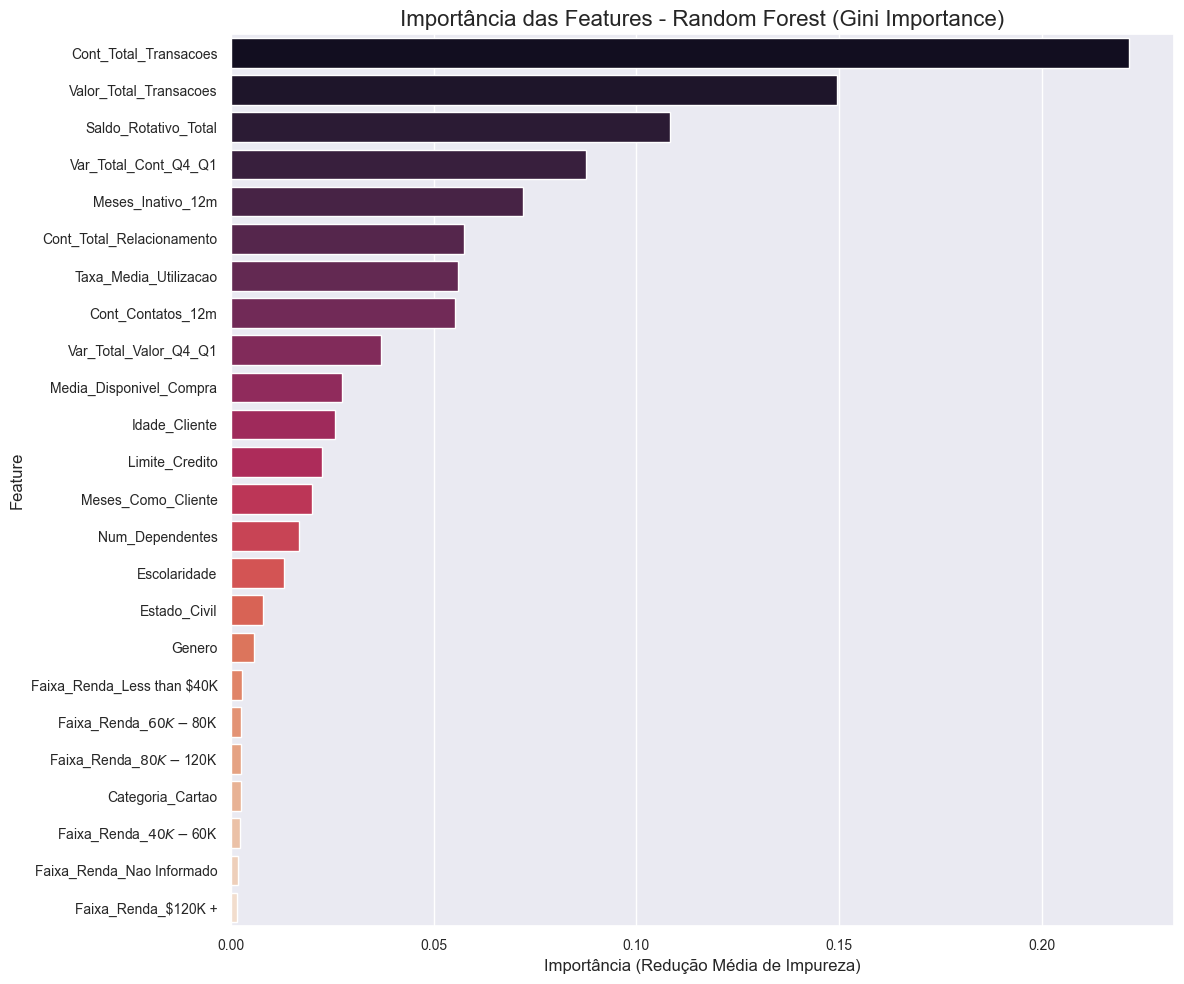


Importância das Features (Random Forest):

                       Feature  Importancia
15       Cont_Total_Transacoes     0.221400
14      Valor_Total_Transacoes     0.149442
11        Saldo_Rotativo_Total     0.108306
16        Var_Total_Cont_Q4_Q1     0.087462
8            Meses_Inativo_12m     0.071935
7    Cont_Total_Relacionamento     0.057563
17       Taxa_Media_Utilizacao     0.055922
9            Cont_Contatos_12m     0.055221
13       Var_Total_Valor_Q4_Q1     0.036933
12     Media_Disponivel_Compra     0.027501
0                Idade_Cliente     0.025715
10              Limite_Credito     0.022590
6           Meses_Como_Cliente     0.020076
2              Num_Dependentes     0.016972
3                 Escolaridade     0.013191
4                 Estado_Civil     0.007993
1                       Genero     0.005836
22  Faixa_Renda_Less than $40K     0.002758
20     Faixa_Renda_$60K - $80K     0.002573
21    Faixa_Renda_$80K - $120K     0.002495
5             Categoria_Cartao  

In [85]:
# Verificar se o modelo_rf está treinado (exemplo)

try:
    # Obter as importâncias das features do modelo Random Forest
    importancias_rf = rf_model_base.feature_importances_

    # Obter os nomes das colunas a partir do X_treino original
    nomes_features = X_train_cols

    # Criar um DataFrame para associar features e suas importâncias
    importancia_rf_df = pd.DataFrame({
        'Feature': nomes_features,
        'Importancia': importancias_rf
    })

    # Ordenar o DataFrame pela importância, do maior para o menor
    importancia_rf_df = importancia_rf_df.sort_values(by='Importancia', ascending=False)

    # Configurar o tamanho do gráfico
    plt.figure(figsize=(12, 10))

    # Criar o gráfico de barras usando Seaborn
    sns.barplot(x='Importancia', y='Feature', data=importancia_rf_df, palette='rocket')

    # Adicionar título e rótulos aos eixos
    plt.title('Importância das Features - Random Forest (Gini Importance)', fontsize=16)
    plt.xlabel('Importância (Redução Média de Impureza)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Exibir o gráfico
    plt.tight_layout()
    plt.show()

    # Exibir o DataFrame com as importâncias
    print("\nImportância das Features (Random Forest):\n")
    print(importancia_rf_df.to_string())

except NameError:
    print("Certifique-se de que a variável 'rf_model_base' e 'X_train' existem e o modelo foi treinado.")

c:\Users\jhona\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


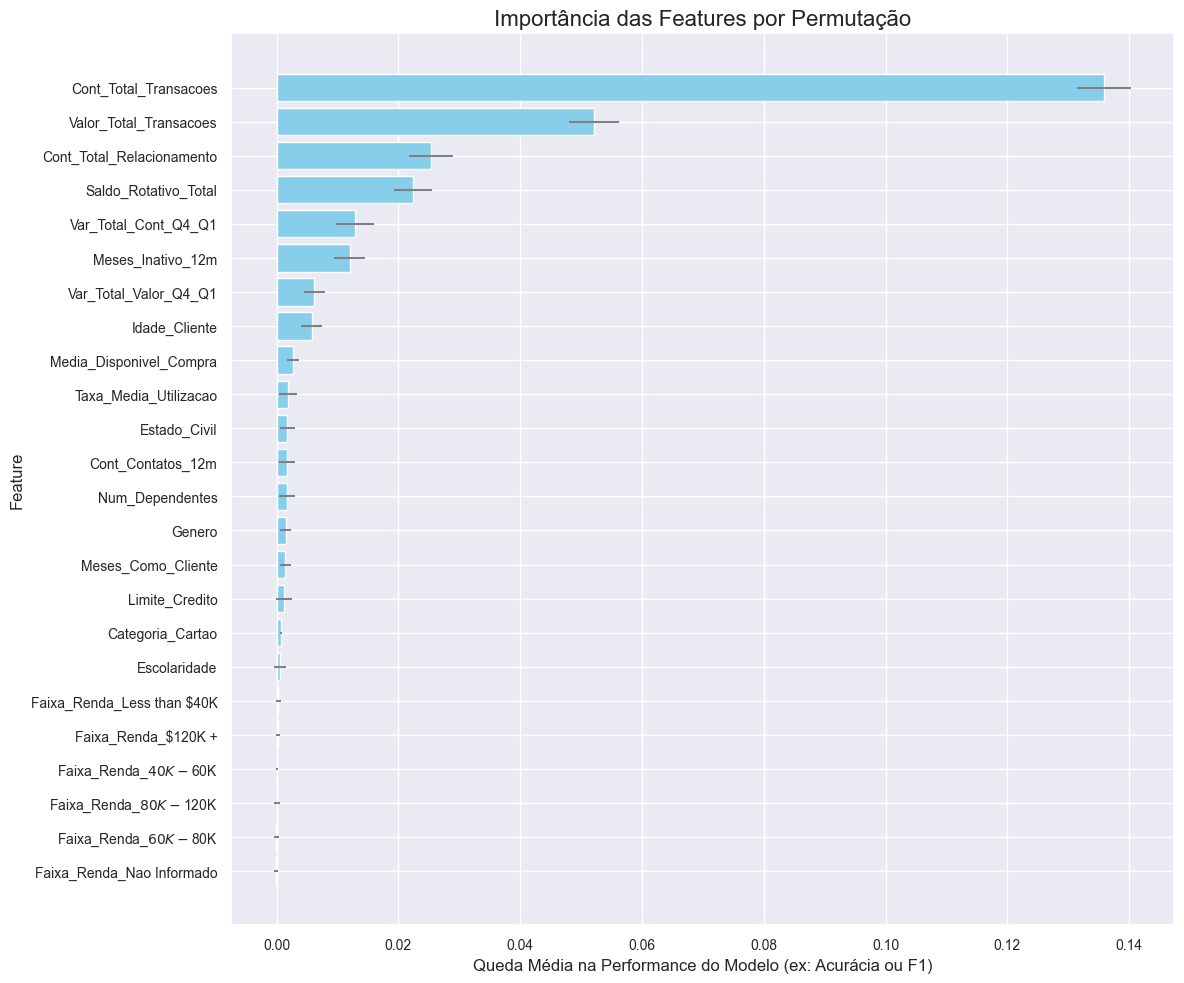


Importância das Features (Permutação):

                       Feature  Importancia_Media  Desvio_Padrao
15       Cont_Total_Transacoes           0.135835       0.004483
14      Valor_Total_Transacoes           0.052106       0.004168
7    Cont_Total_Relacionamento           0.025382       0.003658
11        Saldo_Rotativo_Total           0.022380       0.003058
16        Var_Total_Cont_Q4_Q1           0.012849       0.003169
8            Meses_Inativo_12m           0.011980       0.002501
13       Var_Total_Valor_Q4_Q1           0.006214       0.001781
0                Idade_Cliente           0.005740       0.001771
12     Media_Disponivel_Compra           0.002686       0.000980
17       Taxa_Media_Utilizacao           0.001922       0.001491
4                 Estado_Civil           0.001790       0.001205
9            Cont_Contatos_12m           0.001711       0.001295
2              Num_Dependentes           0.001711       0.001303
1                       Genero           0.001474

In [86]:
# Escolha o modelo final para a análise de permutação
# Substitua 'modelo_rf' se o seu modelo final for outro
modelo_para_permutacao = rf_model_base

# Verificar se as variáveis necessárias existem
try:
    # Calcular a importância por permutação
    # Usamos X_teste_scaler e y_teste para avaliar em dados não vistos
    # n_repeats define quantas vezes cada feature é permutada (para robustez)
    resultado_permutacao = permutation_importance(
        modelo_para_permutacao,
        X_test_scaled_array,
        y_test,
        n_repeats=15,       
        random_state=42,    
        n_jobs=-1           
    )

    # Obter os nomes das colunas
    nomes_features = X_train_cols

    # Obter a média e o desvio padrão das importâncias
    importancias_perm_media = resultado_permutacao.importances_mean
    importancias_perm_std = resultado_permutacao.importances_std

    # Criar um DataFrame com os resultados
    importancia_perm_df = pd.DataFrame({
        'Feature': nomes_features,
        'Importancia_Media': importancias_perm_media,
        'Desvio_Padrao': importancias_perm_std
    })

    # Ordenar o DataFrame pela importância média
    importancia_perm_df = importancia_perm_df.sort_values(by='Importancia_Media', ascending=False)

    # Configurar o tamanho do gráfico
    plt.figure(figsize=(12, 10))

    # Criar o gráfico de barras horizontais com barras de erro
    plt.barh(
        importancia_perm_df['Feature'],
        importancia_perm_df['Importancia_Media'],
        xerr=importancia_perm_df['Desvio_Padrao'], # Adiciona barras de erro
        align='center',
        color='skyblue',
        ecolor='gray'
    )

    # Inverter o eixo Y para que a feature mais importante fique no topo
    plt.gca().invert_yaxis()

    # Adicionar título e rótulos
    plt.title('Importância das Features por Permutação', fontsize=16)
    plt.xlabel('Queda Média na Performance do Modelo (ex: Acurácia ou F1)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Exibir o gráfico
    plt.tight_layout()
    plt.show()

    # Exibir o DataFrame com as importâncias
    print("\nImportância das Features (Permutação):\n")
    print(importancia_perm_df.to_string())

except NameError:
    print("Certifique-se de que 'rf_model_base', 'X_train', 'X_test_scaled_array' e 'y_test' existem.")
